# Data Profiler - Practical Work

practical part of Pr1. - Data Profiler

## 1. Importing libraries




In [4]:
!pip -q install ydata-profiling


^C


In [5]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import sqlite3

print("Libraries imported successfully!")


Libraries imported successfully!


## 2. Reading CSV data




In [6]:
# If running in Colab after uploading the project folder, adjust this path if needed.
CSV_PATH = "../data/customers.csv"

df = pd.read_csv(CSV_PATH)
print("CSV loaded successfully!")
df.head()


CSV loaded successfully!


,CustomerID,Age,Gender,Income,Orders,Purchases,City,SignupDate
0,C001,21.0,Male,25000.0,3,4500,Indore,10-01-2025
1,C002,25.0,Female,32000.0,5,7200,Surat,15-02-2025
2,C003,29.0,Male,45000.0,7,12000,Bhopal,05-03-2025
3,C004,35.0,Female,55000.0,10,18500,Pune,22-03-2025
4,C005,42.0,Male,62000.0,8,21000,Mumbai,11-04-2025


## 3. Reading JSON data


In [8]:
JSON_PATH = "../data/customers.json"

json_df = pd.read_json(JSON_PATH)

print("JSON loaded successfully!")
json_df.head()


JSON loaded successfully!


,CustomerID,Age,Gender,Income,Orders,Purchases,City,SignupDate
0,C001,21.0,Male,25000.0,3,4500,Indore,2025-01-10
1,C002,25.0,Female,32000.0,5,7200,Surat,2025-02-15
2,C003,29.0,Male,45000.0,7,12000,Bhopal,2025-03-05
3,C004,35.0,Female,55000.0,10,18500,Pune,2025-03-22
4,C005,42.0,Male,62000.0,8,21000,Mumbai,2025-04-11


In [9]:
print("Rows:", json_df.shape[0])
print("Columns:", json_df.shape[1])


Rows: 16
Columns: 8


## 4. Reading data using SQL

In [10]:
DB_PATH = "../data/customers.db"

conn = sqlite3.connect(DB_PATH)

sql_df = pd.read_sql_query("SELECT * FROM customers", conn)

print("SQL data loaded successfully!")
sql_df.head()


SQL data loaded successfully!


,CustomerID,Age,Gender,Income,Orders,Purchases,City,SignupDate
0,C001,21.0,Male,25000.0,3,4500,Indore,2025-01-10
1,C002,25.0,Female,32000.0,5,7200,Surat,2025-02-15
2,C003,29.0,Male,45000.0,7,12000,Bhopal,2025-03-05
3,C004,35.0,Female,55000.0,10,18500,Pune,2025-03-22
4,C005,42.0,Male,62000.0,8,21000,Mumbai,2025-04-11


In [11]:
query = """
SELECT CustomerID, Age, Gender, Income, Orders, Purchases
FROM customers
WHERE Income > 40000
"""

result = pd.read_sql_query(query, conn)
result


,CustomerID,Age,Gender,Income,Orders,Purchases
0,C003,29.0,Male,45000.0,7,12000
1,C004,35.0,Female,55000.0,10,18500
2,C005,42.0,Male,62000.0,8,21000
3,C007,31.0,Male,48000.0,6,13500
4,C008,45.0,Female,70000.0,12,28000
5,C010,38.0,Female,58000.0,9,19500
6,C012,33.0,Male,50000.0,7,14500
7,C013,NaN,Female,42000.0,5,9800
8,C015,30.0,None,47000.0,6,12500
9,C005,42.0,Male,62000.0,8,21000


In [12]:
conn.close()


## 5. Getting data from a REST API


In [13]:
url = "https://jsonplaceholder.typicode.com/users"

response = requests.get(url, timeout=15)

print("Status Code:", response.status_code)
response.raise_for_status()


Status Code: 200


In [14]:
api_data = response.json()

api_df = pd.DataFrame(api_data)

print("Number of API records:", len(api_data))
api_df.head()


Number of API records: 10


,id,name,username,email,address,phone,website,company
0,1,Leanne Graham,Bret,Sincere@april.biz,"{'street': 'Kulas Light', 'suite': 'Apt. 556',...",1-770-736-8031 x56442,hildegard.org,"{'name': 'Romaguera-Crona', 'catchPhrase': 'Mu..."
1,2,Ervin Howell,Antonette,Shanna@melissa.tv,"{'street': 'Victor Plains', 'suite': 'Suite 87...",010-692-6593 x09125,anastasia.net,"{'name': 'Deckow-Crist', 'catchPhrase': 'Proac..."
2,3,Clementine Bauch,Samantha,Nathan@yesenia.net,"{'street': 'Douglas Extension', 'suite': 'Suit...",1-463-123-4447,ramiro.info,"{'name': 'Romaguera-Jacobson', 'catchPhrase': ..."
3,4,Patricia Lebsack,Karianne,Julianne.OConner@kory.org,"{'street': 'Hoeger Mall', 'suite': 'Apt. 692',...",493-170-9623 x156,kale.biz,"{'name': 'Robel-Corkery', 'catchPhrase': 'Mult..."
4,5,Chelsey Dietrich,Kamren,Lucio_Hettinger@annie.ca,"{'street': 'Skiles Walks', 'suite': 'Suite 351...",(254)954-1289,demarco.info,"{'name': 'Keebler LLC', 'catchPhrase': 'User-c..."


## 6. Understanding the data


In [15]:
print("First 5 rows:")
display(df.head())

print("\nDataset shape:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())


First 5 rows:


,CustomerID,Age,Gender,Income,Orders,Purchases,City,SignupDate
0,C001,21.0,Male,25000.0,3,4500,Indore,10-01-2025
1,C002,25.0,Female,32000.0,5,7200,Surat,15-02-2025
2,C003,29.0,Male,45000.0,7,12000,Bhopal,05-03-2025
3,C004,35.0,Female,55000.0,10,18500,Pune,22-03-2025
4,C005,42.0,Male,62000.0,8,21000,Mumbai,11-04-2025



Dataset shape: (16, 8)

Column names:
['CustomerID', 'Age', 'Gender', 'Income', 'Orders', 'Purchases', 'City', 'SignupDate']


In [16]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16 entries, 0 to 15
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   CustomerID  16 non-null     object 
 1   Age         15 non-null     float64
 2   Gender      15 non-null     object 
 3   Income      15 non-null     float64
 4   Orders      16 non-null     int64  
 5   Purchases   16 non-null     int64  
 6   City        16 non-null     object 
 7   SignupDate  16 non-null     object 
dtypes: float64(2), int64(2), object(4)
memory usage: 1.1+ KB


In [18]:
df.describe(include="all")


,CustomerID,Age,Gender,Income,Orders,Purchases,City,SignupDate
count,16,15.000000,15,15.000000,16.00000,16.000000,16,16
unique,15,NaN,2,NaN,NaN,NaN,7,15
top,C005,NaN,Male,NaN,NaN,NaN,Indore,11-04-2025
freq,2,NaN,8,NaN,NaN,NaN,3,2
mean,NaN,32.600000,NaN,46466.666667,6.50000,13875.000000,NaN,NaN
std,NaN,7.595111,NaN,13346.303216,2.65832,7172.307857,NaN,NaN
min,NaN,21.000000,NaN,25000.000000,2.00000,3500.000000,NaN,NaN
25%,NaN,27.000000,NaN,36500.000000,4.75000,7800.000000,NaN,NaN
50%,NaN,31.000000,NaN,47000.000000,6.50000,13000.000000,NaN,NaN
75%,NaN,39.500000,NaN,56500.000000,8.00000,19875.000000,NaN,NaN


In [19]:
print("Data types:")
print(df.dtypes)


Data types:
CustomerID     object
Age           float64
Gender         object
Income        float64
Orders          int64
Purchases       int64
City           object
SignupDate     object
dtype: object


## 7. Checking missing values and duplicates


In [20]:
print("Missing values by column:")
print(df.isnull().sum())

print("\nTotal missing values:", df.isnull().sum().sum())

print("\nDuplicate rows:", df.duplicated().sum())


Missing values by column:
CustomerID    0
Age           1
Gender        1
Income        1
Orders        0
Purchases     0
City          0
SignupDate    0
dtype: int64

Total missing values: 3

Duplicate rows: 1


## 8. Cleaning the data


In [21]:
clean_df = df.copy()

clean_df["Age"] = clean_df["Age"].fillna(clean_df["Age"].median())
clean_df["Income"] = clean_df["Income"].fillna(clean_df["Income"].median())
clean_df["Gender"] = clean_df["Gender"].fillna(clean_df["Gender"].mode()[0])

before = len(clean_df)
clean_df = clean_df.drop_duplicates()
after = len(clean_df)

print("Rows before duplicate removal:", before)
print("Rows after duplicate removal:", after)

print("\nRemaining missing values:")
print(clean_df.isnull().sum())


Rows before duplicate removal: 16
Rows after duplicate removal: 15

Remaining missing values:
CustomerID    0
Age           0
Gender        0
Income        0
Orders        0
Purchases     0
City          0
SignupDate    0
dtype: int64


### Removing an identifier for analysis


In [22]:
analysis_df = clean_df.drop(columns=["CustomerID"])
analysis_df.head()


,Age,Gender,Income,Orders,Purchases,City,SignupDate
0,21.0,Male,25000.0,3,4500,Indore,10-01-2025
1,25.0,Female,32000.0,5,7200,Surat,15-02-2025
2,29.0,Male,45000.0,7,12000,Bhopal,05-03-2025
3,35.0,Female,55000.0,10,18500,Pune,22-03-2025
4,42.0,Male,62000.0,8,21000,Mumbai,11-04-2025


# 9. Univariate EDA


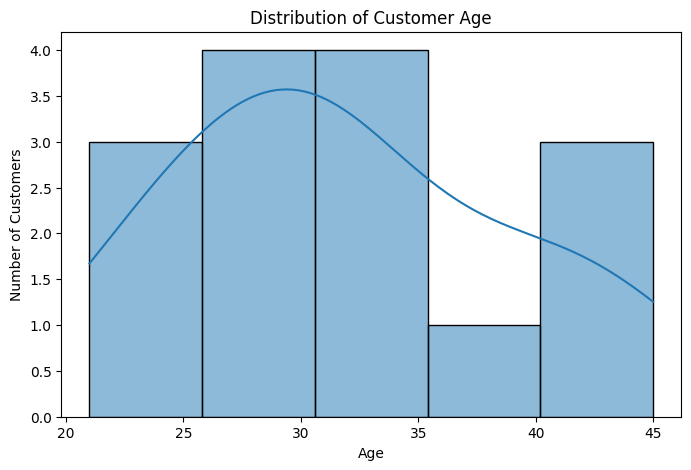

In [23]:
plt.figure(figsize=(8, 5))
sns.histplot(clean_df["Age"], kde=True)
plt.title("Distribution of Customer Age")
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.show()


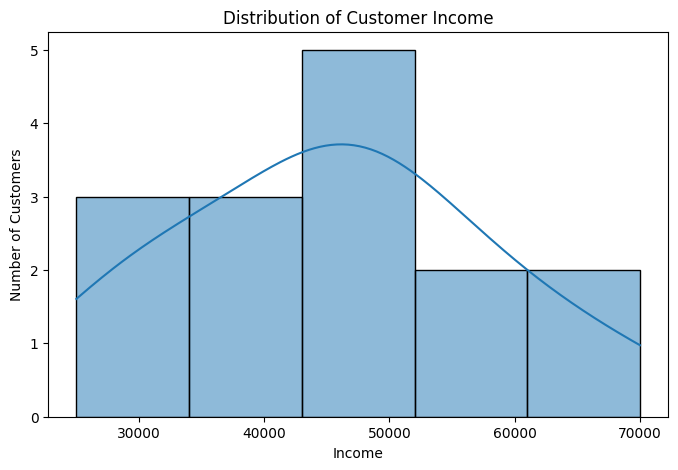

In [24]:
plt.figure(figsize=(8, 5))
sns.histplot(clean_df["Income"], kde=True)
plt.title("Distribution of Customer Income")
plt.xlabel("Income")
plt.ylabel("Number of Customers")
plt.show()


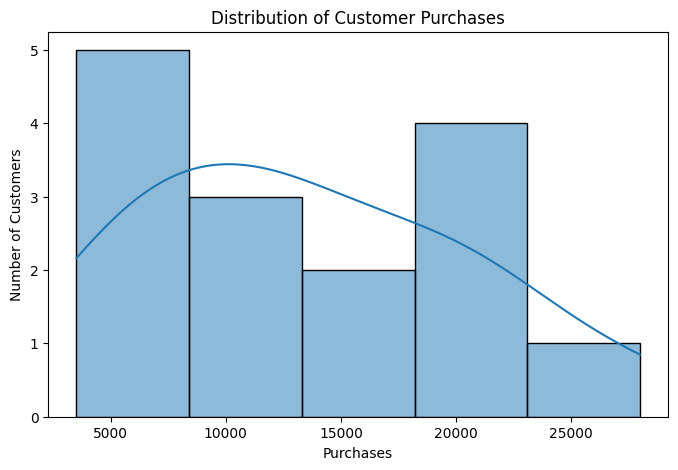

In [25]:
plt.figure(figsize=(8, 5))
sns.histplot(clean_df["Purchases"], kde=True)
plt.title("Distribution of Customer Purchases")
plt.xlabel("Purchases")
plt.ylabel("Number of Customers")
plt.show()


# 10. Bivariate EDA


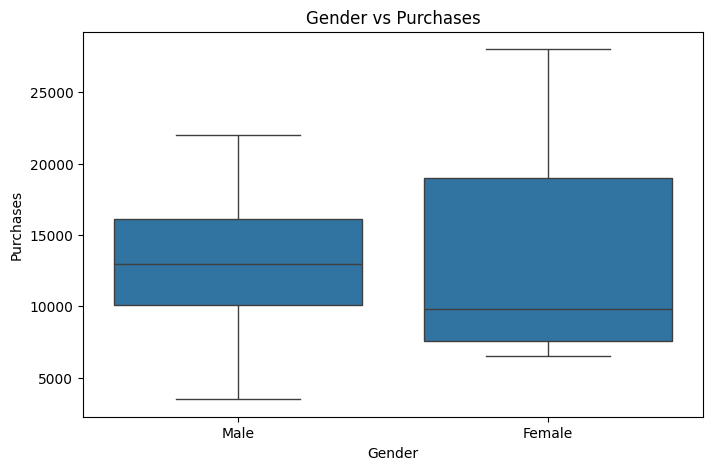

In [26]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=clean_df, x="Gender", y="Purchases")
plt.title("Gender vs Purchases")
plt.xlabel("Gender")
plt.ylabel("Purchases")
plt.show()


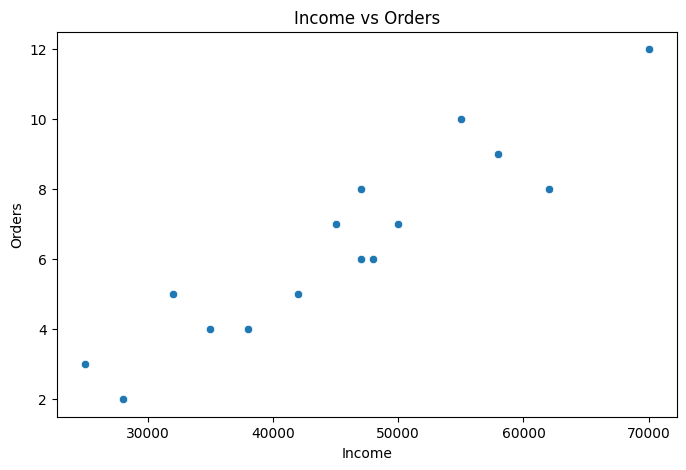

In [27]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=clean_df, x="Income", y="Orders")
plt.title("Income vs Orders")
plt.xlabel("Income")
plt.ylabel("Orders")
plt.show()


# 11. Multivariate EDA



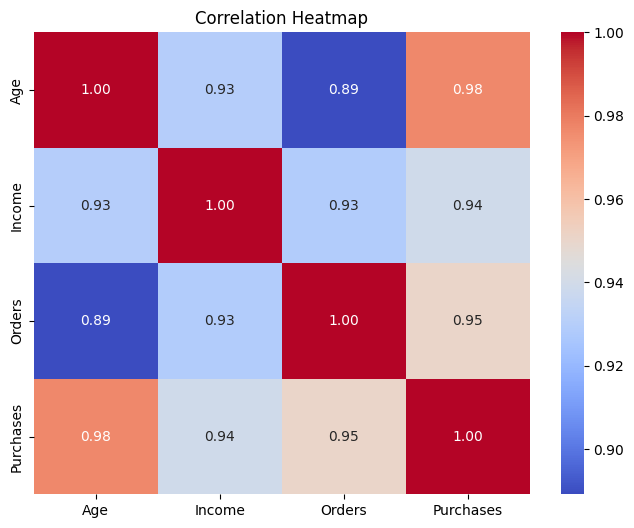

In [28]:
numeric_df = clean_df.select_dtypes(include="number")

plt.figure(figsize=(8, 6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


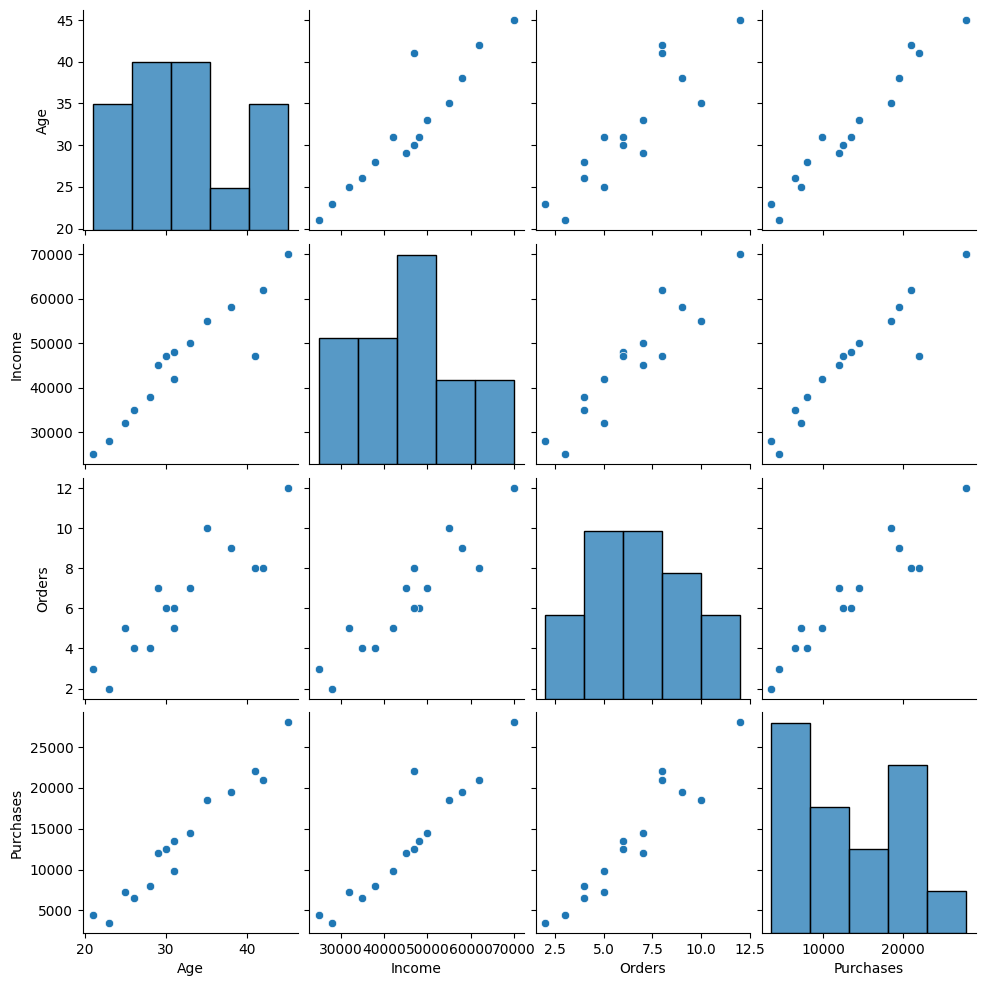

In [29]:
sns.pairplot(clean_df[["Age", "Income", "Orders", "Purchases"]])
plt.show()
